In [2]:
import numpy as np
import glob, re, os

def find_folders(root):
    """Map N -> path of its NMentropy_swap.txt file, from subfolders named N<N>."""
    folders = {}
    for path in glob.glob(os.path.join(root, "N*")):
        if not os.path.isdir(path):
            continue
        m = re.fullmatch(r"N(\d+)", os.path.basename(path))
        if not m:
            continue
        N = int(m.group(1))
        fpath = os.path.join(path, "NMentropy_swap.txt")
        if os.path.isfile(fpath):
            folders[N] = fpath
    return dict(sorted(folders.items()))

def load_all(root):
    files = find_folders(root)
    if not files:
        raise FileNotFoundError(f"No N<N>/NMentropy_swap.txt files found under {root}")
    
    N_values = np.array(list(files.keys()))
    g_ref = None
    entropy = None
    error = None
    
    for i, N in enumerate(N_values):
        arr = np.loadtxt(files[N], comments='#')
        arr = arr[arr[:,0].argsort()]
        g, S, err = arr[:,0], arr[:,1], arr[:,2]
        
        if g_ref is None:
            g_ref = g
            entropy = np.full((len(N_values), len(g_ref)), np.nan)
            error   = np.full((len(N_values), len(g_ref)), np.nan)
        else:
            assert np.allclose(g, g_ref), f"g-grid mismatch in N={N}"
        
        entropy[i, :] = S
        error[i, :]   = err
    
    return N_values, g_ref, entropy, error

N_values, g_values, entropy, error = load_all('results/28may2026/')

def f(N, g, tol=1e-6):
    """Return [entropy, error] for given N and g."""
    i = np.searchsorted(N_values, N)
    assert N_values[i] == N, f"N={N} not in dataset"
    j = np.argmin(np.abs(g_values - g))
    assert abs(g_values[j] - g) < tol, f"g={g} not on grid (closest {g_values[j]})"
    return np.array([entropy[i, j], error[i, j]])

In [3]:
import numpy as np
from scipy.optimize import curve_fit


def linear_model(x, a, b):
    return a * x + b

def linear_fit_Svs_g(g_values, entropy, error):
    # popt contains optimal parameters [slope, intercept]
    # pcov is the 2x2 covariance matrix
    popt, pcov = curve_fit(linear_model, g_values, entropy, sigma=error, absolute_sigma=True)

    slope = popt[0]
    # The [0, 0] element corresponds to the variance of the first parameter (slope)
    slope_error = np.sqrt(pcov[0, 0])
    return slope, slope_error

In [4]:
gmin = 0.5
gmin_index = int(np.where(g_values==gmin)[0][0])
glist = g_values[gmin_index:]

Nmin = 4
Nmin_index = int(np.where(N_values==Nmin)[0][0])
Nlist = N_values[Nmin_index:]

data = entropy[Nmin_index:,gmin_index:]
data_err = error[Nmin_index:,gmin_index:]
# err_safe = np.where(data_err > 0, data_err, np.nanmedian(data_err[data_err > 0]))

sizeN = len(Nlist)
slopes = np.zeros((sizeN,2))

for i in range(sizeN):
    slopes[i,:] = linear_fit_Svs_g(glist, data[i,:], data_err[i,:])

import matplotlib.pyplot as plt

# plt.plot(Nlist,slopes[:,0])
# plt.show()

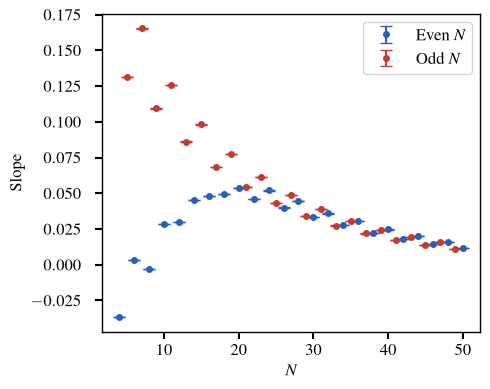

In [5]:
blue = (40/255, 95/255, 185/255)
red = (195/255, 58/255, 50/255)
# orange = (236/255, 133/255, 54/255)
# green = (85/255, 157/255, 155/255)
# blue = (0/255, 114/255, 178/255)
# red = (213/255, 94/255, 0/255)
green = (0/255, 158/255, 115/255)
orange = (230/255, 159/255, 0/255)
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'''
    \usepackage{nicefrac}
    \usepackage{siunitx}
    \usepackage{physics} 
    \usepackage[mathcal]{eucal}
    \DeclareFontFamily{OT1}{mathc}{}
    \DeclareFontShape{OT1}{mathc}{m}{it}{<-> mathc10}{}
    \DeclareMathAlphabet{\mathcal}{OT1}{mathc}{m}{it}
    '''
)
plt.rc('font', family='serif',serif='Times')
FontSize=12
tickpad=10

fig, ax = plt.subplots(figsize=(5, 4))
ax.errorbar(Nlist[0::2] ,slopes[:,0][0::2], yerr=slopes[:,1][0::2], fmt='o', ms=4, color=blue, label=r"Even $N$",capsize=4)
ax.errorbar(Nlist[1::2] ,slopes[:,0][1::2], yerr=slopes[:,1][1::2], fmt='o', ms=4, color=red, label=r"Odd $N$",capsize=4)
ax.set_xlabel(r"$N$", fontsize=FontSize)
ax.set_ylabel(r"Slope", fontsize=FontSize)
# ax.set_title("S vs g for fixed N")
ax.legend(fontsize=FontSize)
ax.grid(alpha=0.3)
ax.xaxis.set_tick_params(width=1.5, length=5, labelsize=FontSize)
ax.yaxis.set_tick_params(width=1.5, length=5, labelsize=FontSize, pad=tickpad)

plt.setp(ax.spines.values(), linewidth=1)
plt.grid(False)
plt.tight_layout()

plt.savefig("slopes_vs_N.png",format = 'png', dpi=600)
plt.show()

array([[-0.00000000e+00,  1.13044609e-02,  4.36486831e-02, ...,
         7.41834994e-02,  7.49604599e-02,  7.61984157e-02],
       [-0.00000000e+00,  1.00005000e-04,  1.40098092e-03, ...,
         5.09003424e-01,  5.18376563e-01,  5.19918385e-01],
       [-0.00000000e+00,  1.79973006e-04,  2.18761156e-03, ...,
         9.51185812e-02,  9.69603190e-02,  9.41881627e-02],
       ...,
       [-0.00000000e+00, -0.00000000e+00, -0.00000000e+00, ...,
         7.31493477e-02,  7.61430455e-02,  7.57510643e-02],
       [-0.00000000e+00, -0.00000000e+00, -0.00000000e+00, ...,
         5.71207623e-02,  5.78198030e-02,  5.84345159e-02],
       [-2.22044605e-16, -0.00000000e+00, -0.00000000e+00, ...,
         5.77412164e-02,  5.85697800e-02,  6.01079803e-02]],
      shape=(47, 69))

In [13]:
int(np.where(N_values==Nlist[1])[0][0])

26

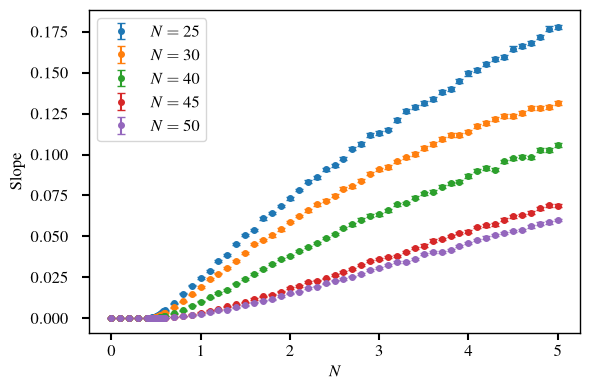

In [33]:
fig, ax = plt.subplots(figsize=(6, 4))
Nlist = [25,30,40,45,50]

for n in Nlist:
    i = int(np.where(N_values==n)[0][0])

    ax.errorbar(g_values , entropy[i,:], yerr=error[i,:], fmt='o', ms=4, label=rf"$N={n}$",capsize=3)

ax.set_xlabel(r"$N$", fontsize=FontSize)
ax.set_ylabel(r"Slope", fontsize=FontSize)
# ax.set_title("S vs g for fixed N")
ax.legend(fontsize=FontSize)
ax.grid(alpha=0.3)
ax.xaxis.set_tick_params(width=1.5, length=5, labelsize=FontSize)
ax.yaxis.set_tick_params(width=1.5, length=5, labelsize=FontSize, pad=tickpad)

plt.setp(ax.spines.values(), linewidth=1)
plt.grid(False)
plt.tight_layout()

plt.savefig("slopes_vs_N.png",format = 'png', dpi=600)
plt.show()

In [ ]:
import numpy as np
from numpy.polynomial import Polynomial
from scipy.optimize import curve_fit

# ---------- Fit 1: S(g) at fixed N -> polynomial ----------

def fit_poly_vs_g(N_values, g_values, entropy, error, N, degree=6, auto_reduce=True, verbose=True):
    """
    Weighted polynomial fit of S(g) at fixed N.
    
    If auto_reduce=True: checks the actual numerical rank of the fit and, if the
    requested degree exceeds what the data can support (given g-spacing and weights),
    automatically lowers the degree until the fit is full-rank. This avoids the
    "poorly conditioned" RankWarning at its source, rather than silently producing
    a fit whose high-order coefficients are numerically meaningless.
    """
    i = np.searchsorted(N_values, N)
    assert N_values[i] == N, f"N={N} not in dataset"
    
    g = g_values
    S = entropy[i, :]
    err = error[i, :]
    err_safe = np.where(err > 0, err, np.nanmedian(err[err > 0]))
    weights = 1.0 / err_safe
    
    deg_used = degree
    while deg_used > 0:
        poly, extra = Polynomial.fit(g, S, deg=deg_used, w=weights, full=True)
        rank = extra[1]
        if rank == deg_used + 1 or not auto_reduce:
            break
        deg_used -= 1
    
    if deg_used != degree and verbose:
        print(f"  [N={N}] requested degree={degree} is rank-deficient for this data; "
              f"using degree={deg_used} instead")
    
    residuals = S - poly(g)
    chi2 = np.sum((residuals / err_safe) ** 2)
    dof = len(g) - (deg_used + 1)
    chi2_red = chi2 / dof if dof > 0 else np.nan
    
    return {"coeffs": poly.convert().coef, "poly": poly, "degree_requested": degree,
            "degree_used": deg_used, "chi2": chi2, "chi2_red": chi2_red, "dof": dof}


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# from fitting import fit_poly_vs_g, fit_gaussian_vs_N, gaussian

# ---------- Plot 1: S vs g, for specific N values ----------

def plot_S_vs_g(N_values, g_values, entropy, error, N_list, degree=6, show_fit=True, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    
    g_fine = np.linspace(g_values.min(), g_values.max(), 400)
    
    for N in N_list:
        i = np.searchsorted(N_values, N)
        assert N_values[i] == N, f"N={N} not in dataset"
        
        S = entropy[i, :]
        err = error[i, :]
        
        line = ax.errorbar(g_values, S, yerr=err, fmt='o', ms=3, capsize=2,
                            label=f"N={N} (data)", alpha=0.7)
        
        if show_fit:
            color = line[0].get_color()
            res = fit_poly_vs_g(N_values, g_values, entropy, error, N, degree=degree)
            ax.plot(g_fine, res["poly"](g_fine), '-', color=color,
                    label=f"N={N} fit (deg={degree}, χ²ᵣ={res['chi2_red']:.2f})")
    
    ax.set_xlabel("g")
    ax.set_ylabel("Entropy S")
    ax.set_title("S vs g for fixed N")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    return ax